## 3. Logistic Regression

### 3.1 Packages importeren 

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    f1_score, roc_auc_score, classification_report, accuracy_score
)
import glob
from datetime import datetime
from scipy import stats

from preprocessing import(
    my_preprocessor,
    my_tokenizer,
)
from helpfuncties import load_dataset

### 3.2 Dataset inladen 

In [19]:
df = load_dataset()
y = df['Product']
X = df['Omschrijving']

### 3.3 Train-Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42, stratify=y)

### 3.4 Pipeline + Hyperparameter Tuning

#### 3.4.1 Logistic Regression Pipeline

In [4]:
logreg_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer( # TF-IDF vectorizer met de preprocesser en tokenizer van hierboven 
        preprocessor=my_preprocessor,
        tokenizer=my_tokenizer,
        analyzer='word', # werkt op woord niveau (geen characters, geen zinnen)
        ngram_range=(1,2), # unigrams = 'credit', bigrams = 'credit card'. Verbetert de prestaties van het mmodel 
        token_pattern=None # None want danb word onze custom tokenizer gebruikt
    )),
    ('model', LogisticRegression(max_iter=10000, class_weight='balanced', n_jobs=-1))   # Logistische regressie model met gebalanceerde klassengewichten
])

#### 3.4.2 RandomizedSearchCV

In [5]:
random_params = {
    'model__C': stats.loguniform(1e-3, 200),
    'model__class_weight': ['balanced', None],
    'model__solver': ['lbfgs', 'saga'],
    'tfidf__min_df': [1, 2, 3, 4, 5],
    'tfidf__max_df': [0.75, 0.8, 0.9, 1.0],
    'tfidf__ngram_range': [(1,1), (1,2), (1,3)],
    'tfidf__max_features': [30000, 50000, None],
    'tfidf__sublinear_tf': [True, False],
    'tfidf__norm': ['l2', None],
    'tfidf__binary': [False, True],
    'tfidf__use_idf': [True, False]
}

random_search = RandomizedSearchCV(
    logreg_pipeline,
    param_distributions=random_params,
    n_iter=80,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)
best = random_search.best_params_

Fitting 3 folds for each of 80 candidates, totalling 240 fits


#### 3.4.3 GridSearchCV

In [6]:
grid_params = {
    'model__C': [
        best['model__C'] * 0.5,
        best['model__C'],
        best['model__C'] * 2
    ],
    'model__class_weight': [best['model__class_weight']],
    'model__solver': [best['model__solver']],
    
    'tfidf__min_df': [
        max(1, best['tfidf__min_df'] - 1),
        best['tfidf__min_df'],
        best['tfidf__min_df'] + 1
    ],
    'tfidf__max_df': [best['tfidf__max_df']],
    'tfidf__ngram_range': [best['tfidf__ngram_range']],
    'tfidf__max_features': [best['tfidf__max_features']],
    'tfidf__sublinear_tf': [best['tfidf__sublinear_tf']],
    'tfidf__norm': [best['tfidf__norm']],
    'tfidf__binary': [best['tfidf__binary']],
    'tfidf__use_idf': [best['tfidf__use_idf']]
}

In [7]:
grid = GridSearchCV(
    logreg_pipeline,
    param_grid=grid_params,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
logreg_pipeline = grid.best_estimator_

Fitting 3 folds for each of 9 candidates, totalling 27 fits


#### 3.4.4 Cross-validation (betrouwbaarheid testen)

In [8]:
scores = cross_val_score(logreg_pipeline, X_train, y_train, cv=5, scoring='f1_weighted')
print("CV F1-score:", scores.mean())
print("CV F1-scores per fold:", scores)

CV F1-score: 0.8545593594184051
CV F1-scores per fold: [0.85617416 0.85603053 0.85108319 0.84714051 0.86236842]


### 3.6 Evaluatie Modelprestaties 

#### 3.6.1 Voorspellingen

In [9]:
y_pred_test = logreg_pipeline.predict(X_test)
y_proba_test = logreg_pipeline.predict_proba(X_test)
y_pred_train = logreg_pipeline.predict(X_train)
y_proba_train = logreg_pipeline.predict_proba(X_train)

#### 3.6.2 Totale metrics

In [15]:
test_accuracy_logreg = accuracy_score(y_test, y_pred_test)
test_f1_logreg = f1_score(y_test, y_pred_test, average='weighted')
train_accuracy_logreg = accuracy_score(y_train, y_pred_train)
train_f1_logreg = f1_score(y_train, y_pred_train, average='weighted')

print("Testset: ")
print(f'Accuracy Logistic Regression: {test_accuracy_logreg:.2f}')
print(f"F1 Logistic Regression: {test_f1_logreg:.2f}")

print("\nTrainset: ")
print(f'Accuracy Logistic Regression TRAINSET: {train_accuracy_logreg:.2f}')
print(f"F1 Logistic Regression TRAINSET: {train_f1_logreg:.2f}")

Testset: 
Accuracy Logistic Regression: 0.85
F1 Logistic Regression: 0.85

Trainset: 
Accuracy Logistic Regression TRAINSET: 1.00
F1 Logistic Regression TRAINSET: 1.00


#### 3.6.3 Classification report

In [16]:
print("Testset Classification Report Logistic Regression:")
print(classification_report(y_test, y_pred_test))

Testset Classification Report Logistic Regression:
                    precision    recall  f1-score   support

      Bankrekening       0.87      0.85      0.86       447
Consumentenkrediet       0.78      0.54      0.64       284
        Creditcard       0.83      0.80      0.82       565
         Hypotheek       0.92      0.94      0.93       994
           Incasso       0.83      0.88      0.86      1229
Kredietregistratie       0.84      0.86      0.85       948

          accuracy                           0.85      4467
         macro avg       0.84      0.81      0.82      4467
      weighted avg       0.85      0.85      0.85      4467



In [17]:
print("Trainset Classification Report Logistic Regression:")
print(classification_report(y_train, y_pred_train))

Trainset Classification Report Logistic Regression:
                    precision    recall  f1-score   support

      Bankrekening       1.00      1.00      1.00      1042
Consumentenkrediet       1.00      1.00      1.00       663
        Creditcard       1.00      1.00      1.00      1319
         Hypotheek       1.00      1.00      1.00      2320
           Incasso       1.00      1.00      1.00      2865
Kredietregistratie       1.00      1.00      1.00      2211

          accuracy                           1.00     10420
         macro avg       1.00      1.00      1.00     10420
      weighted avg       1.00      1.00      1.00     10420



#### 3.6.4 Confusion Matrix

[[ 378    3   31   13   14    8]
 [   7  153   17   19   62   26]
 [  27    6  453   11   47   21]
 [  15    8    5  932   16   18]
 [   4   15   17   26 1087   80]
 [   4   11   23   14   83  813]]


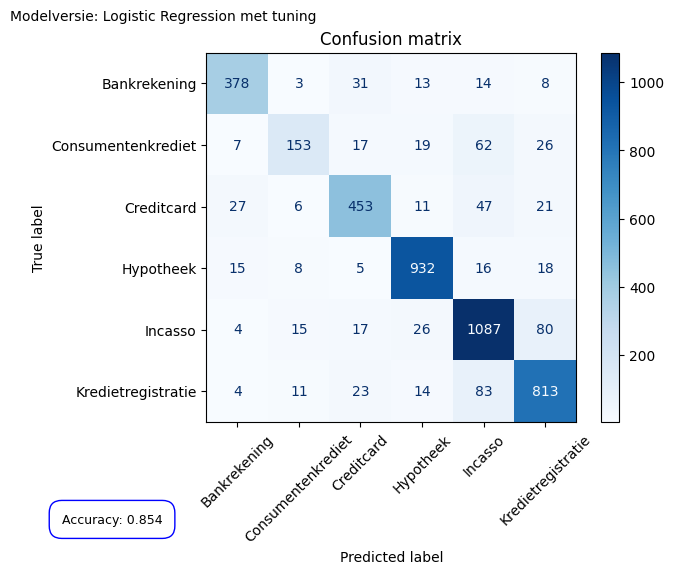

In [13]:
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    cmap='Blues'
)
plt.xticks(rotation=45)
plt.title('Confusion matrix')
plt.suptitle("Modelversie: Logistic Regression met tuning", fontsize=10, x=0.1, y=0.97) # ! naam aanpassen per modelversie
plt.figtext(0.02, -0.1, f"Accuracy: {test_accuracy_logreg:.3f}", ha='center', fontsize=9, color='black', bbox=dict(facecolor='none', edgecolor='blue', boxstyle='round,pad=1'))
plt.savefig("afbeeldingen/confusion_matrix_logreg_met_tuning.png", dpi=300, bbox_inches='tight') # ! naam aanpassen per modelversie
plt.show()

#### 3.6.5 AUC-score (multiclass)

In [14]:
auc_logreg = roc_auc_score(y_test, y_proba_test, multi_class='ovr')
print(f"AUC: {auc_logreg:.3f}")

AUC: 0.970
